# Analisis en WSL

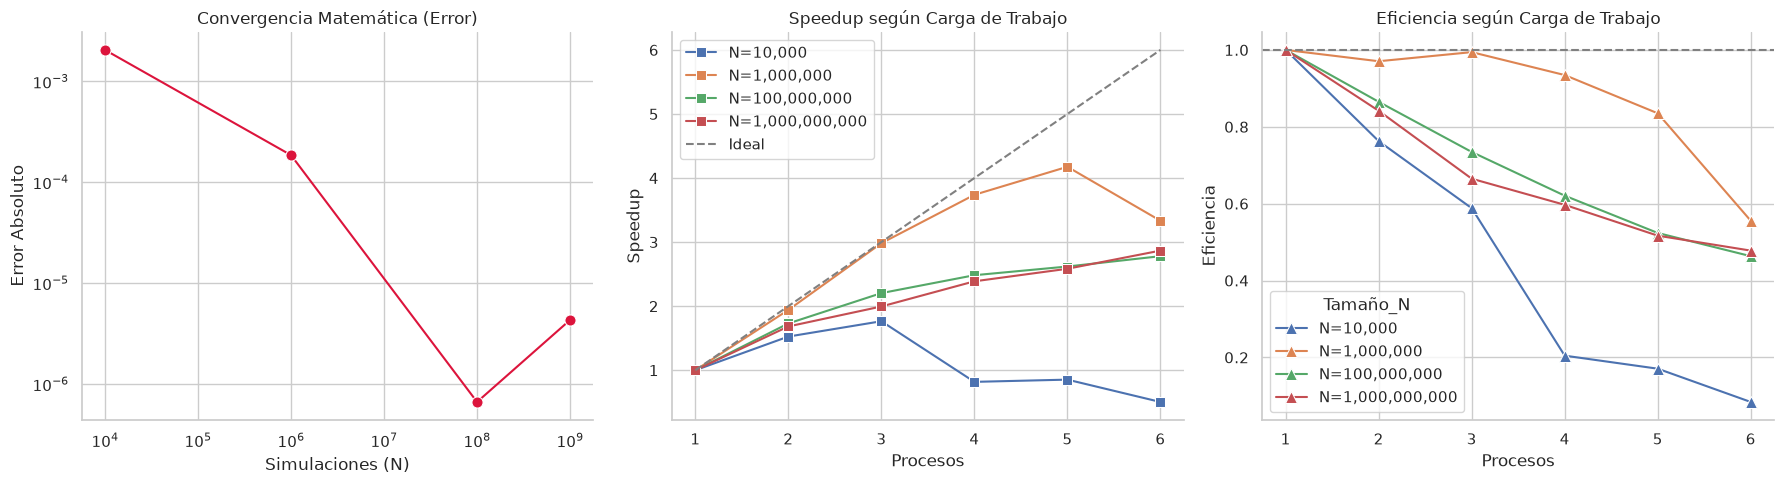


--- RESUMEN DE CONVERGENCIA ---
 N_Simulaciones  Integral_Estimada  Error_Absoluto
          10000           0.335388    2.054667e-03
        1000000           0.333519    1.861667e-04
      100000000           0.333334    6.666667e-07
     1000000000           0.333329    4.333333e-06


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuracion minimalista global
sns.set_theme(style="whitegrid", palette="deep")

# 1. Carga y reducción de datos
df = pd.read_csv('programa_hpc_x2_resultados.csv')
df_median = df.groupby(['N_Simulaciones', 'Procesos']).median().reset_index()

# 2. Calculos Matematicos (Error)
VALOR_ANALITICO = 1.0 / 3.0
df_median['Error_Absoluto'] = np.abs(df_median['Integral_Estimada'] - VALOR_ANALITICO)

# 3. Calculos de Rendimiento (T1 independiente para cada N)
t1_por_n = df_median[df_median['Procesos'] == 1].set_index('N_Simulaciones')['Tiempo']
df_median['T1'] = df_median['N_Simulaciones'].map(t1_por_n)

df_median['Speedup'] = df_median['T1'] / df_median['Tiempo']
df_median['Eficiencia'] = df_median['Speedup'] / df_median['Procesos']

# Formatear la etiqueta de N para la leyenda (ej: "N=10,000")
df_median['Tamaño_N'] = df_median['N_Simulaciones'].apply(lambda x: f"N={x:,}")

# =========================================================
# 4. Generacion de Graficos (1x3)
# =========================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: Convergencia del Error (Filtramos solo la corrida secuencial)
df_error = df_median[df_median['Procesos'] == 1]
sns.lineplot(data=df_error, x='N_Simulaciones', y='Error_Absoluto', 
             marker='o', markersize=8, color='crimson', ax=ax1)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Convergencia Matemática (Error)')
ax1.set_xlabel('Simulaciones (N)')
ax1.set_ylabel('Error Absoluto')

# Grafico B: Speedup Multilinea
sns.lineplot(data=df_median, x='Procesos', y='Speedup', hue='Tamaño_N', 
             marker='s', markersize=7, ax=ax2)
procesos_unicos = df_median['Procesos'].unique()
sns.lineplot(x=procesos_unicos, y=procesos_unicos, linestyle='--', color='gray', label='Ideal', ax=ax2)
ax2.set_title('Speedup según Carga de Trabajo')
ax2.set_ylabel('Speedup')

# Grafico C: Eficiencia Multilinea
sns.lineplot(data=df_median, x='Procesos', y='Eficiencia', hue='Tamaño_N', 
             marker='^', markersize=8, ax=ax3)
ax3.axhline(y=1.0, linestyle='--', color='gray', label='Ideal')
ax3.set_title('Eficiencia según Carga de Trabajo')
ax3.set_ylabel('Eficiencia')

# Limpieza visual y renderizado
sns.despine()
plt.tight_layout()
plt.show()

# Imprimir resumen de datos
print("\n--- RESUMEN DE CONVERGENCIA ---")
print(df_error[['N_Simulaciones', 'Integral_Estimada', 'Error_Absoluto']].to_string(index=False))